In [48]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [49]:
iris = load_iris()

In [50]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
X = iris.data
y = iris.target

In [26]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [27]:
X.shape

(150, 4)

In [28]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

<Axes: >

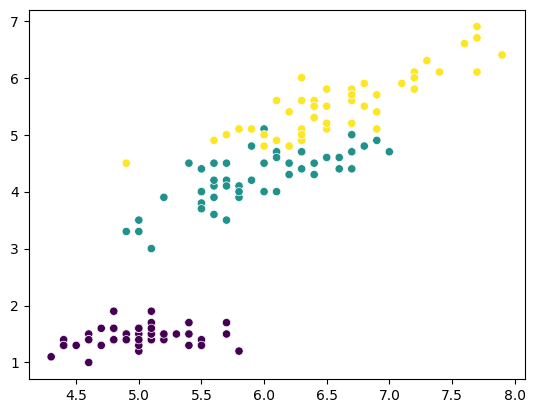

In [76]:
sns.scatterplot(x=X[:,0],y=X[:,2], c=y)

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
#dimentionality Reducation - PCA

from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)

In [85]:
# Elbow Methos

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

In [86]:
wcss 

[574.8792432000097,
 197.40381604541264,
 115.21629013217192,
 90.09715237543348,
 66.59290724830595,
 57.07033876393032,
 50.47442003861179,
 42.612988232817855,
 34.9612007451671,
 29.06129718764983]

<Axes: >

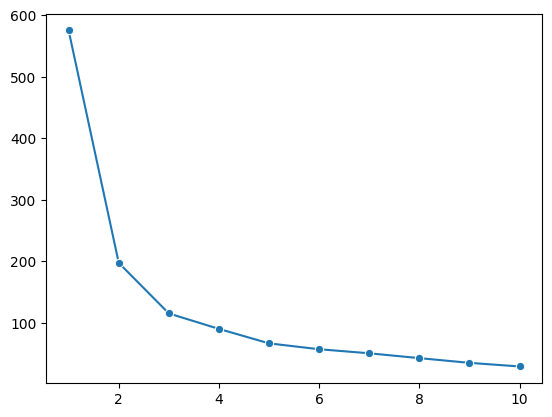

In [87]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

<Axes: >

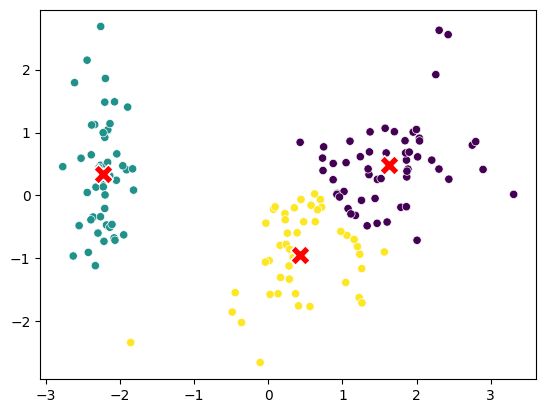

In [99]:
kmeans = KMeans(n_clusters=3, random_state=10)

labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker="X", color = "red", s=200)

<Axes: >

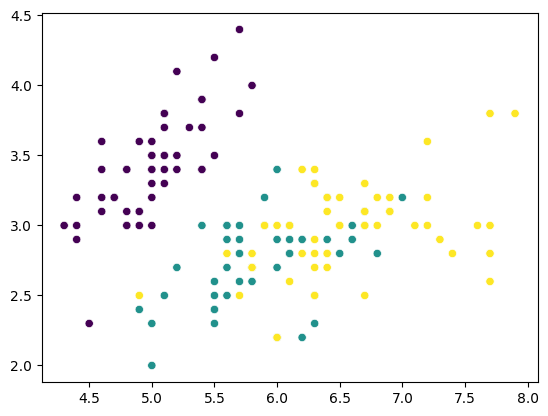

In [91]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=y)